Assignment 2


 * Name: Shlok Nikam
* PRN: 12414145



*   Batch: 2
*   Division: D



*   Branch: CSE(AI)
*   Date: 6/1/2026


2. Perform the following operations using  Python on the data sets:

Compute and display summary statistics for each feature available in the dataset. (e.g. minimum value, maximum value, mean, range, standard deviation, variance and percentiles
Illustrate the feature distributions using histogram.
Data cleaning, Data integration, Data transformation, Data model building (e.g. Classification)


Importing and using a messy DataFrame

Imports pandas. Creates a plot/visualization.


In [93]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

noisy_data = {
    'StudentID': [101, 102, 103, 104, 105, 106, 107, 108,
                  109, 110, 111, 112, 113, 114, 115, 115],

    'NAME': ['Aarav', 'Diya', 'Rohan', 'Sneha', 'Karan', 'Isha',
             None, 'Pooja', 'Rahul', 'Neha', 'Aman', 'Priya',
             'Sahil', 'Ananya', 'Vikram', 'Vikram'],

    'AGE': [19, 200, 18, 21, -5, 19, 22, None,
            20, 19, 21, 22, 'twenty', 18, 23, 23],

    'GENDER': ['M', 'F', 'Male', 'F', 'M', 'female',
               'M', 'F', 'M', None, 'M', 'F',
               'M', 'F', 'M', 'M'],

    'DEPARTMENT': ['CSE', 'IT', 'CSE', 'ECE', 'ME', 'cse',
                   'IT', 'ECE ', 'ME', 'CSE', 'IT', None,
                   'CSE', 'ME', 'IT', 'IT'],

    'MARKS': [85, 190, 78, np.nan, 72, 95,
              -10, 84, np.nan, 92, 76, 89,
              830, 68, None, 91],

    'ATTENDANCE': [92, 95, 188, 90, np.nan, 98,
                   89, None, 80, 96, -20, 93,
                   90, 82, 94, 94],

    'INTERNSHIP': ['Yes', 'Yes', 'No', 'YES', 'No', 'yes',
                   'No', 'Yes', None, 'Yes', 'No', 'Yes',
                   'Y', 'No', 'Yes', 'Yes']
}

df = pd.DataFrame(noisy_data)
print(df)


    StudentID    NAME     AGE  GENDER DEPARTMENT  MARKS  ATTENDANCE INTERNSHIP
0         101   Aarav      19       M        CSE   85.0        92.0        Yes
1         102    Diya     200       F         IT  190.0        95.0        Yes
2         103   Rohan      18    Male        CSE   78.0       188.0         No
3         104   Sneha      21       F        ECE    NaN        90.0        YES
4         105   Karan      -5       M         ME   72.0         NaN         No
5         106    Isha      19  female        cse   95.0        98.0        yes
6         107    None      22       M         IT  -10.0        89.0         No
7         108   Pooja    None       F       ECE    84.0         NaN        Yes
8         109   Rahul      20       M         ME    NaN        80.0       None
9         110    Neha      19    None        CSE   92.0        96.0        Yes
10        111    Aman      21       M         IT   76.0       -20.0         No
11        112   Priya      22       F       None   8

Printing preliminary info

Prints output to the console.


In [94]:
print(df.shape)      # rows & columns
print(df.info())     # data types & null values
print(df.describe()) # numerical summary


(16, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16 entries, 0 to 15
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   StudentID   16 non-null     int64  
 1   NAME        15 non-null     object 
 2   AGE         15 non-null     object 
 3   GENDER      15 non-null     object 
 4   DEPARTMENT  15 non-null     object 
 5   MARKS       13 non-null     float64
 6   ATTENDANCE  14 non-null     float64
 7   INTERNSHIP  15 non-null     object 
dtypes: float64(2), int64(1), object(5)
memory usage: 1.1+ KB
None
        StudentID       MARKS  ATTENDANCE
count   16.000000   13.000000   14.000000
mean   108.437500  141.538462   90.071429
std      4.661455  211.011301   41.174048
min    101.000000  -10.000000  -20.000000
25%    104.750000   76.000000   89.250000
50%    108.500000   85.000000   92.500000
75%    112.250000   92.000000   94.750000
max    115.000000  830.000000  188.000000


Null values

Prints output to the console.


In [95]:
print(df.isnull().sum())

StudentID     0
NAME          1
AGE           1
GENDER        1
DEPARTMENT    1
MARKS         3
ATTENDANCE    2
INTERNSHIP    1
dtype: int64


Works with a pandas DataFrame.


In [96]:
df['AGE'] = pd.to_numeric(df['AGE'], errors='coerce')


Performs: df['AGE'] = df['AGE'].fillna(df['AGE'].mean())


In [97]:
df['AGE'] = df['AGE'].fillna(df['AGE'].mean())
df['MARKS'] = df['MARKS'].fillna(df['MARKS'].mean())
df['ATTENDANCE'] = df['ATTENDANCE'].fillna(df['ATTENDANCE'].mean())

df['GENDER'] = df['GENDER'].fillna(df['GENDER'].mode()[0])
df['DEPARTMENT'] = df['DEPARTMENT'].fillna(df['DEPARTMENT'].mode()[0])
df['INTERNSHIP'] = df['INTERNSHIP'].fillna(df['INTERNSHIP'].mode()[0])


Performs: df['GENDER'] = df['GENDER'].str.lower().str.strip()


In [98]:
df['GENDER'] = df['GENDER'].str.lower().str.strip()
df['GENDER'] = df['GENDER'].replace({'male': 'm', 'female': 'f'})

df['DEPARTMENT'] = df['DEPARTMENT'].str.upper().str.strip()

df['INTERNSHIP'] = df['INTERNSHIP'].str.lower().str.strip()
df['INTERNSHIP'] = df['INTERNSHIP'].replace({'y': 'yes'})


Performs: df.drop_duplicates(subset='StudentID', inplace=True)


In [99]:
df.drop_duplicates(subset='StudentID', inplace=True)


Performs: df['AGE'] = df['AGE'].clip(lower=16, upper=30)


In [100]:
df['AGE'] = df['AGE'].clip(lower=16, upper=30)
df['MARKS'] = df['MARKS'].clip(lower=0, upper=100)
df['ATTENDANCE'] = df['ATTENDANCE'].clip(lower=0, upper=100)


Prints output to the console.


In [101]:
df['AGE'] = df['AGE'].round().astype(int)
df['MARKS'] = df['MARKS'].round().astype(int)
df['ATTENDANCE'] = df['ATTENDANCE'].round().astype(int)

print(df)


    StudentID    NAME  AGE GENDER DEPARTMENT  MARKS  ATTENDANCE INTERNSHIP
0         101   Aarav   19      m        CSE     85          92        yes
1         102    Diya   30      f         IT    100          95        yes
2         103   Rohan   18      m        CSE     78         100         no
3         104   Sneha   21      f        ECE    100          90        yes
4         105   Karan   16      m         ME     72          90         no
5         106    Isha   19      f        CSE     95          98        yes
6         107    None   22      m         IT      0          89         no
7         108   Pooja   30      f        ECE     84          90        yes
8         109   Rahul   20      m         ME    100          80        yes
9         110    Neha   19      m        CSE     92          96        yes
10        111    Aman   21      m         IT     76           0         no
11        112   Priya   22      f         IT     89          93        yes
12        113   Sahil   3

Performs: df.describe()


In [102]:
df.describe()

,StudentID,AGE,MARKS,ATTENDANCE
count,15.000000,15.000000,15.000000,15.000000
mean,108.000000,21.866667,82.600000,85.266667
std,4.472136,4.580497,25.379407,24.176336
min,101.000000,16.000000,0.000000,0.000000
25%,104.500000,19.000000,77.000000,89.500000
50%,108.000000,21.000000,89.000000,90.000000
75%,111.500000,22.500000,100.000000,94.500000
max,115.000000,30.000000,100.000000,100.000000


Defines function `my_mean`.


In [103]:
data = df['MARKS'].dropna().tolist()  # Use 'MARKS' instead of 'Marks'

def my_mean(data):
    return sum(data) / len(data)

print("Mean:", my_mean(data))


Mean: 82.6


Defines function `my_median`.


In [104]:
def my_median(data):
    sorted_data = sorted(data)
    n = len(sorted_data)
    if n % 2 == 0:
        return (sorted_data[n//2 - 1] + sorted_data[n//2]) / 2
    else:
        return sorted_data[n//2]

print("Median:", my_median(data))
print("Pandas Median:", df['MARKS'].median())


Median: 89
Pandas Median: 89.0


Defines function `my_mode`.


In [105]:

def my_mode(data):
    freq = {}
    for x in data:
        freq[x] = freq.get(x, 0) + 1
    return max(freq, key=freq.get)

print("Mode:", my_mode(data))

print("Mode of Marks column: ", df['MARKS'].mode()[0])

Mode: 100
Mode of Marks column:  100


Defines function `my_variance`.


In [106]:
def my_variance(data):
    mean = sum(data) / len(data)
    squared_diff = [(x - mean) ** 2 for x in data]
    return sum(squared_diff) / len(data)

print("Variance:", my_variance(data))
print("Pandas Variance:", df['MARKS'].var(ddof=0))  # ddof=0 for population variance


Variance: 601.1733333333334
Pandas Variance: 601.1733333333334


Defines function `my_std`.


In [107]:
def my_std(data):
    variance = my_variance(data)
    return variance ** 0.5

print("Standard Deviation:", my_std(data))
print("Pandas Std:", df['MARKS'].std(ddof=0))


Standard Deviation: 24.518836296474866
Pandas Std: 24.518836296474866


Defines function `my_percentile`.


In [108]:
def my_percentile(data, percentile):
    sorted_data = sorted(data)
    n = len(sorted_data)
    index = (percentile / 100) * (n - 1)

    if index.is_integer():
        return sorted_data[int(index)]
    else:
        lower = int(index)
        upper = lower + 1
        fraction = index - lower
        return sorted_data[lower] + fraction * (sorted_data[upper] - sorted_data[lower])

print("25th Percentile:", my_percentile(data, 25))
print("50th Percentile:", my_percentile(data, 50))
print("75th Percentile:", my_percentile(data, 75))
print("Pandas 25th:", df['MARKS'].quantile(0.25))
print("Pandas 50th:", df['MARKS'].quantile(0.50))
print("Pandas 75th:", df['MARKS'].quantile(0.75))


25th Percentile: 77.0
50th Percentile: 89
75th Percentile: 100.0
Pandas 25th: 77.0
Pandas 50th: 89.0
Pandas 75th: 100.0


Defines function `my_range_stats`.


In [109]:
def my_range_stats(data):
    minimum = min(data)
    maximum = max(data)
    range_val = maximum - minimum
    return {"min": minimum, "max": maximum, "range": range_val}

stats = my_range_stats(data)
print(f"Min: {stats['min']}, Max: {stats['max']}, Range: {stats['range']}")
print(f"Pandas Min: {df['MARKS'].min()}, Max: {df['MARKS'].max()}, Range: {df['MARKS'].max() - df['MARKS'].min()}")


Min: 0, Max: 100, Range: 100
Pandas Min: 0, Max: 100, Range: 100


Performs: df.isnull().sum()


In [110]:
df.isnull().sum()

,0
StudentID,0
NAME,1
AGE,0
GENDER,0
DEPARTMENT,0
MARKS,0
ATTENDANCE,0
INTERNSHIP,0


Prints output to the console.


In [111]:
# Create a copy to preserve original data
df_filled = df.copy()

# Numerical columns → fill with mean
df_filled['AGE'] = df_filled['AGE'].fillna(df_filled['AGE'].mean())
df_filled['MARKS'] = df_filled['MARKS'].fillna(df_filled['MARKS'].mean())
df_filled['ATTENDANCE'] = df_filled['ATTENDANCE'].fillna(df_filled['ATTENDANCE'].mean())

# Categorical columns → fill with mode
df_filled['NAME'] = df_filled['NAME'].fillna(df_filled['NAME'].mode()[0])
df_filled['GENDER'] = df_filled['GENDER'].fillna(df_filled['GENDER'].mode()[0])
df_filled['DEPARTMENT'] = df_filled['DEPARTMENT'].fillna(df_filled['DEPARTMENT'].mode()[0])
df_filled['INTERNSHIP'] = df_filled['INTERNSHIP'].fillna(df_filled['INTERNSHIP'].mode()[0])

# Check if any missing values remain
print(df_filled.isnull().sum())


StudentID     0
NAME          0
AGE           0
GENDER        0
DEPARTMENT    0
MARKS         0
ATTENDANCE    0
INTERNSHIP    0
dtype: int64


Imports matplotlib.pyplot. Creates a plot/visualization.


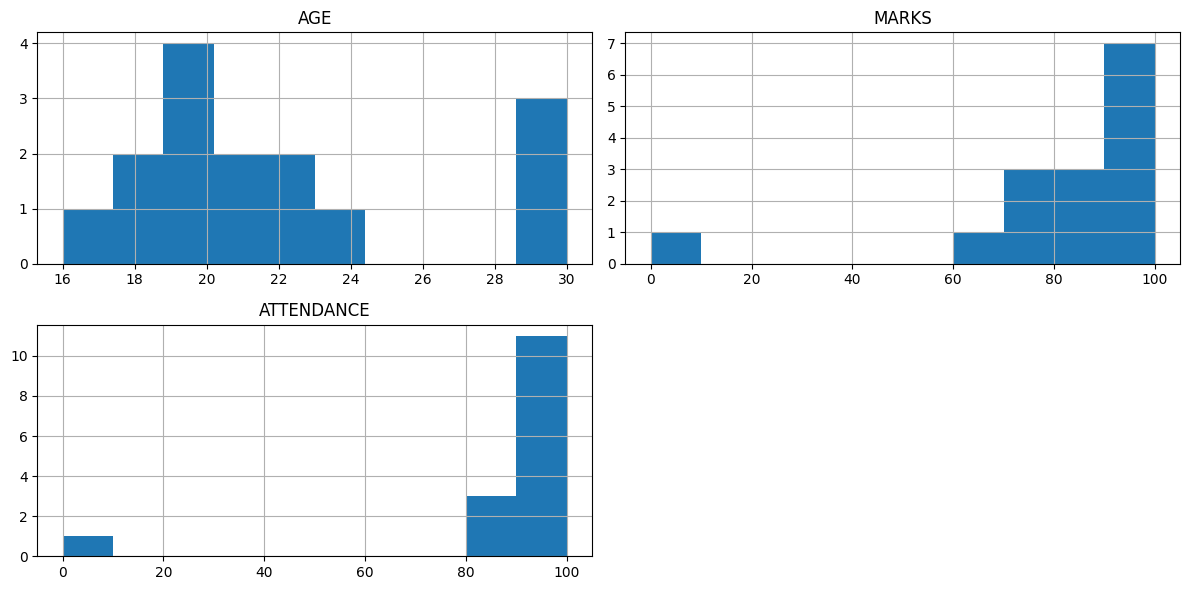

In [112]:
import matplotlib.pyplot as plt

# Only plot numerical columns
df_filled[['AGE', 'MARKS', 'ATTENDANCE']].hist(figsize=(12, 6), bins=10)
plt.tight_layout()
plt.show()


Works with a pandas DataFrame.


In [92]:
# Create performance categories based on MARKS
df_filled['Performance Category'] = pd.cut(
    df_filled['MARKS'],
    bins=[0, 70, 85, 100],
    labels=['Low', 'Medium', 'High']
)

# Display the result
print(df_filled[['MARKS', 'Performance Category']].head(10))


   MARKS Performance Category
0     85               Medium
1    100                 High
2     78               Medium
3    100                 High
4     72               Medium
5     95                 High
6      0                  NaN
7     84               Medium
8    100                 High
9     92                 High


Imports sklearn.


In [113]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder

# Prepare features and target
X = df_filled[['AGE', 'MARKS', 'ATTENDANCE']]
y = df_filled['INTERNSHIP']

# Encode target variable (yes/no to 1/0)
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.3, random_state=42
)

# Train the model
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Accuracy: 1.00

Classification Report:
              precision    recall  f1-score   support

          no       1.00      1.00      1.00         1
         yes       1.00      1.00      1.00         4

    accuracy                           1.00         5
   macro avg       1.00      1.00      1.00         5
weighted avg       1.00      1.00      1.00         5


Confusion Matrix:
[[1 0]
 [0 4]]


Works with a pandas DataFrame.


In [114]:

course_data = pd.DataFrame({
    'StudentID': [101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115],
    'Course': ['Python', 'Java', 'Python', 'C++', 'Java', 'Python', 'C++', 'Java', 'Python', 'Python', 'Java', 'Python', 'C++', 'Java', 'Python'],
    'Grade': ['A', 'B', 'A', 'B', 'C', 'A', 'B', 'B', 'A', 'A', 'C', 'A', 'B', 'B', 'A']
})


df_integrated = df_filled.merge(course_data, on='StudentID', how='inner')
print("\nIntegrated Dataset:")
print(df_integrated.head())
print(f"\nShape after integration: {df_integrated.shape}")



Integrated Dataset:
   StudentID   NAME  AGE GENDER DEPARTMENT  MARKS  ATTENDANCE INTERNSHIP  \
0        101  Aarav   19      m        CSE     85          92        yes   
1        102   Diya   30      f         IT    100          95        yes   
2        103  Rohan   18      m        CSE     78         100         no   
3        104  Sneha   21      f        ECE    100          90        yes   
4        105  Karan   16      m         ME     72          90         no   

   Course Grade  
0  Python     A  
1    Java     B  
2  Python     A  
3     C++     B  
4    Java     C  

Shape after integration: (15, 10)
